<a href="https://colab.research.google.com/github/BillPapakyriakou/DataMining-Notebooks/blob/main/assignment_1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Πρώτη Σειρά Ασκήσεων – Μέρος B
---
### 5324 - Παπακυριακού Βασίλειος

### 5361 - Άννα Ταρασίδου



---
##**Βήμα 1 - Φόρτωση και καθαρισμός των δεδομένων**

In [41]:
import pandas as pd  # pandas
import numpy as np   # numpy
import ast           # ast : abstract syntax trees : χρήση συνάρτησης που μετατρέπει literal σε object, πχ list

# φορτώνει το αρχείο με τα metadata και αγνοεί τις κακές γραμμές
dataframe = pd.read_csv("movies_metadata.csv", low_memory=False, on_bad_lines="skip")

columns_used = ["id", "title", "vote_count", "runtime", "vote_average",
    "revenue", "budget", "release_date", "genres"]    # λίστα με τα πεδία που θα χρησιμοποιήσουμε στο ερωτήματα 1-7

dataframe = dataframe[columns_used].copy()

numeric_columns = ["vote_count", "runtime", "vote_average", "revenue", "budget"]  # πεδία που πρέπει να είναι αριθμοί

for col in numeric_columns:   # για κάθε στήλη numeric
    dataframe[col] = pd.to_numeric(dataframe[col], errors="coerce")   # μετέτρεψε σε numeric (αν δεν είναι ήδη)
                                                                      # όπου δεν γίνεται - μετατροπή σε NaN

dataframe["release_date"] = pd.to_datetime(dataframe["release_date"], errors="coerce")  # μετατροπή σε data format (αν δεν είναι ήδη)
                                                                                        # όπου δεν γίνεται - μετατροπή σε NaN

# κάνει το πεδίο genres αντικείμενο python (λίστα από dictionaries αντί για string)
def fix_genres(val):
    if pd.isna(val):
        return np.nan
    try:
        # μετατροπή string τύπου [{"id":..., "name":...}] list από dictionaries
        return ast.literal_eval(val)
    except:
        return np.nan  # αν δεν γίνεται τότε NaN

dataframe["genres"] = dataframe["genres"].apply(fix_genres)

# αφαιρεί γραμμές με NaN (not a number) από τις columns που μας ενδιαφέρουν
dataframe.dropna(subset=["id", "title", "vote_count", "runtime", "vote_average",
    "revenue", "budget", "release_date", "genres"], inplace=True)

# αφαίρεση γραμμών με παράλογες τιμές

# runtime > 0 και < 300
dataframe = dataframe[(dataframe["runtime"] > 0) & (dataframe["runtime"] < 300)]

# vote_average μεταξύ 0 και 10
dataframe = dataframe[dataframe["vote_average"].between(0, 10)]

# budget και revenue μη αρνητικά
dataframe = dataframe[(dataframe["budget"] >= 0) & (dataframe["revenue"] >= 0)]

# τυπώνουμε συνολικό αριθμό rows και cols των δεδομένων
print("Τελικός αριθμός γραμμών:", dataframe.shape[0])
print("Τελικός αριθμός στηλών:", dataframe.shape[1])

# μερικά extra checks για το dataframe - TODO - περαιτέρω ανάλυση
#dataframe.info()
#dataframe.isna().sum()
#dataframe[numeric_columns].describe()
#dataframe["genres"].head(10)



Τελικός αριθμός γραμμών: 43476
Τελικός αριθμός στηλών: 9


---
##**Βήμα 2 - Ανάλυση κατανομής του πεδίου vote_counts**

### 2.1 Ιστόγραμμα του vote_count (100 bins)

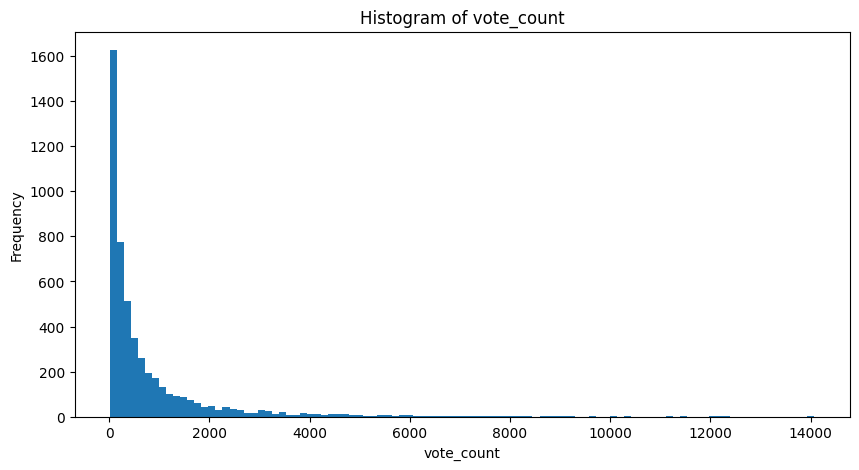

In [48]:
import matplotlib.pyplot as plt

vote_counts = dataframe['vote_count'].values

plt.figure(figsize=(10,5))
plt.hist(vote_counts, bins=100)
plt.title("Histogram of vote_count")
plt.xlabel("vote_count")
plt.ylabel("Frequency")
plt.show()

Από το ιστόγραμμα παρατηρούμε αρχικά ότι η κατανομή είναι right skewed. Η συντιπτική πλειοψηφία των ταινιών έχει πολύ λίγα votes, ενώ οι ταινίες που έχουν πολλά votes (>1000) είναι λίγες. Το συμπέρασμα είναι ότι οι περισσότερες ταινίες παίρνουν λίγη προσοχή ενώ λίγες είναι αυτές που συγκεντρώνουν μεγάλο ενδιαφέρον.

### 2.2 Ιστόγραμμα με εκθετικά bins (log-log plot)

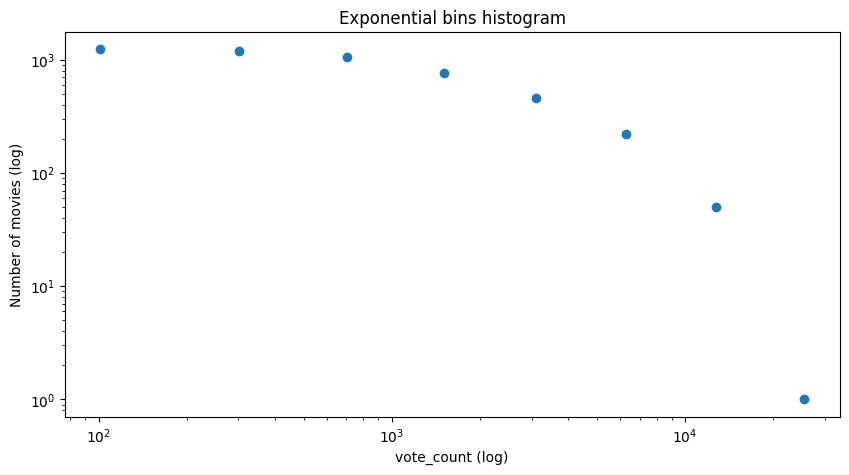

In [49]:
import numpy as np
import matplotlib.pyplot as plt

bins = [1]      # ξεκινάμε από 1
current = 100   # μέγεθος πρώτου κάδου

# βρίσκει το μέγιστο vote_count
max_votes = vote_counts.max()

while bins[-1] < max_votes:
    bins.append(bins[-1] + current)
    current *= 2                     # διπλασιασμός μεγέθους κάδου
bins = np.array(bins)

counts, edges = np.histogram(dataframe["vote_count"], bins=bins)

bin_right_edges = edges[1:]  # δεξιά όρια κάθε κάδου

# point-plot ως προς το δεξί άκρο κάθε κάδου

plt.figure(figsize=(10,5))
plt.scatter(bin_right_edges, counts)
plt.xscale('log')
plt.yscale('log')
plt.title("Exponential bins histogram")
plt.xlabel("vote_count (log)")
plt.ylabel("Number of movies (log)")

plt.show()

Από το scatter plot βλέπουμε καλύτερα τις διαφορές. Παρατηρούμε πιό ομαλή μείωση στον αριθμό των ταινιών όσο ανεβαίνουν τα vote counts καθώς είμαστε σε λογαριθμική κλίμακα. Επιβεβαιώνει το συμπέρασμα ότι οι ταινίες που μαζεύουν πάρα πολλά votes είναι λίγες.

### 2.3 Cumulative frequency plot (log-log)

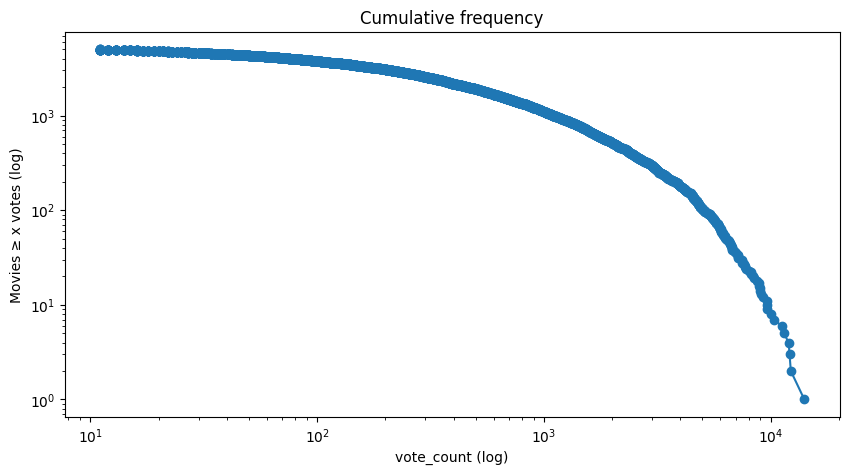

In [50]:
# κάνει ταξινόμηση από τον μικρότερο προς τον μεγαλύτερο αριμθό ψήφων
votes_sorted = np.sort(vote_counts)

# κρατάει αριθμό εγγραφών με τουλάχιστον x ψήφους
cumulative_freq = np.arange(len(votes_sorted), 0, -1)

plt.figure(figsize=(10,5))
plt.plot(votes_sorted, cumulative_freq, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.title("Cumulative frequency")
plt.xlabel("vote_count (log)")
plt.ylabel("Movies ≥ x votes (log)")
plt.show()

Το culuvative frequency διάνυσμα μειώνεται αργά για μικρό αριθμό vote counts και πιό γρήγορα όταν έχουμε μεγάλο αριθμό vote counts. Η εικόνα συνολικά δείχνει ότι:

- έχουμε πολλές ταινίες με λίγα votes
- λίγες ταινίες με πάρα πολλά votes

### 2.4 Zipf plot (log-log)

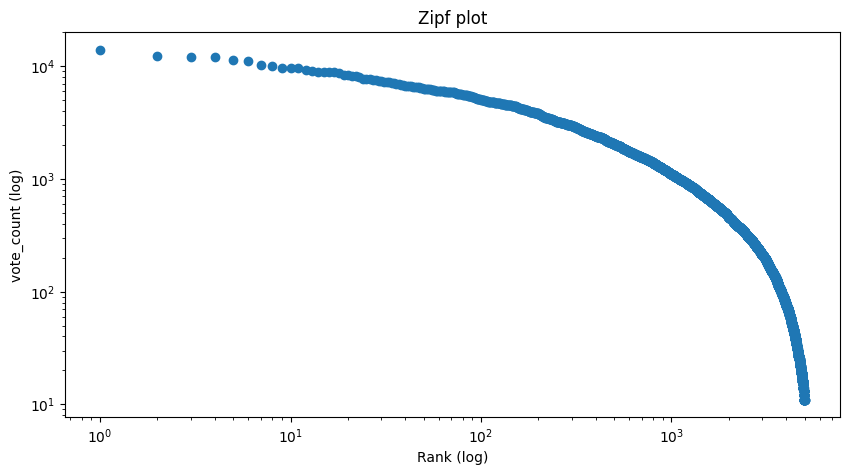

In [51]:
# κάνει ταξινόμηση από τον μεγαλύτερο προς τον μικρότερο αριμθό ψήφων
votes_desc = np.sort(vote_counts)[::-1]

# δημιουργεί τα rank
rank = np.arange(1, len(votes_desc)+1)

plt.figure(figsize=(10,5))
plt.scatter(rank, votes_desc)
plt.xscale('log')
plt.yscale('log')
plt.title("Zipf plot")
plt.xlabel("Rank (log)")
plt.ylabel("vote_count (log)")
plt.show()

Με το Ζipf-plot ταξινομούμε τις ταινίες από δημοφιλή σε λιγότερο δημοφιλή και συγκρίνουμε το rank. Βλέπουμε πιο ξεκάθαρα ότι η πιο δημοφιλής ταινία ξεχωρίζει έντονα, έχοντας αρλετά περισσότερα votes από τις επόμενες. Η διαφορά αυτή συνεχίζει και στις υπόλοιπες δείχνοντας ότι το popularity μειώνεται γρήγορα από την κορυφή πρός τις μικρότερες θέσεις.

### 2.5 Ιστόγραμμα της λογαριθμικής μεταβλητής log_votes (100 bins)

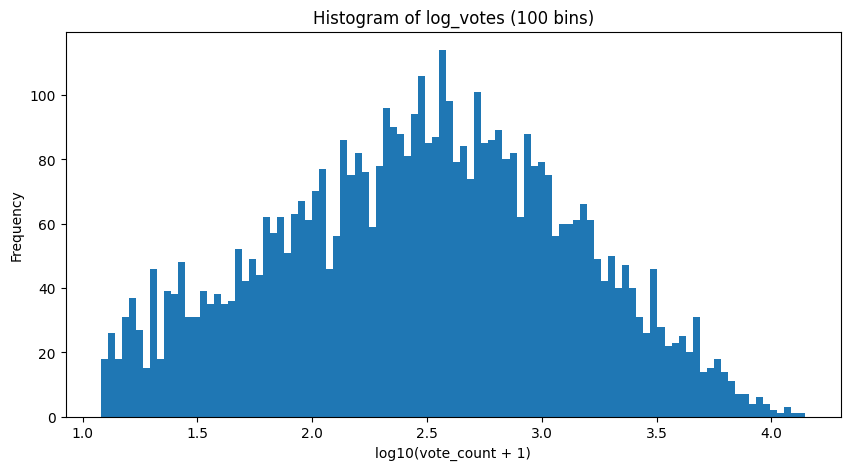

In [52]:
dataframe['log_votes'] = np.log10(dataframe['vote_count'] + 1)  # +1 για να μην έχουμε log(0)

# Ιστόγραμμα με 100 bins
ax = dataframe['log_votes'].plot(kind='hist', bins=100, figsize=(10,5))

ax.set_xlabel("log10(vote_count + 1)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of log_votes (100 bins)")
plt.show()

Παρατηρούμε ότι μετά τη λογαριθμική μετατροπή, η κατανομή μας αρίζει να μοιάζει με την κανονική. Πλέον τα δεδομένα είναι πιό ισορροπημένα και η ανάλυση γίνεται πιό εύκολη καθώς η αρχική κατανομή από το 2.1 ήταν κυριαρχημένη από τα πολύ μικρά ή τα πολύ μεγάλα values.



---
##**Βήμα 3 - Ανάλυση συσχέτισης runtime με vote_average, budget, και revenue**

Number of movies after filtering: 4994


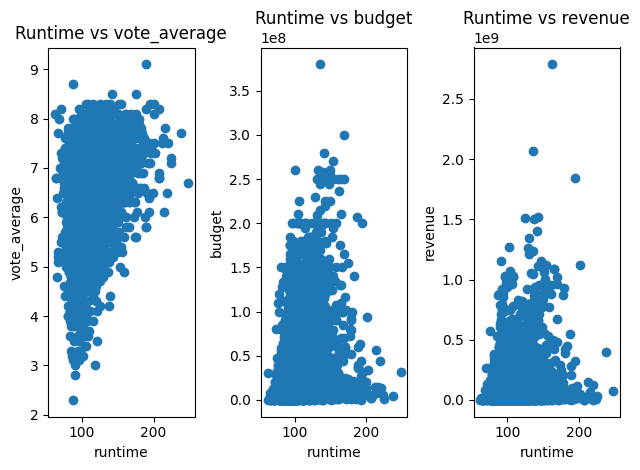

Correlation runtime vs vote_average: 0.363, p-value: 2.488e-155
Correlation runtime vs budget: 0.200, p-value: 4.476e-46
Correlation runtime vs revenue: 0.199, p-value: 5.821e-46


In [53]:
# import για το Pearson Correlation Coefficient
from scipy.stats import pearsonr

# κρατάει τις ταινίες που θέλουμε για να βρούμε τη συσχέτιση
dataframe = dataframe[(dataframe["runtime"] > 30 ) & (dataframe["vote_count"] > 10 ) & (dataframe["budget"] > 20000) & (dataframe["revenue"]  > 20000)]

print("Number of movies after filtering:", len(dataframe))

# πεδία που χρειάζονται για την συσχέτιση
fields = ['vote_average', 'budget', 'revenue']

# scatter plot για κάθε πεδίο
for i, field in enumerate(fields):
    plt.subplot(1, 3, i+1)
    plt.scatter(dataframe['runtime'], dataframe[field])
    plt.xlabel("runtime")
    plt.ylabel(field)
    plt.title(f"Runtime vs {field}")

plt.tight_layout()
plt.show()

for field in fields:
    corr, p_value = pearsonr(dataframe['runtime'], dataframe[field])
    print(f"Correlation runtime vs {field}: {corr:.3f}, p-value: {p_value:.3e}")